# 🏛️ MDM DJBC — Master Data Management untuk Direktorat Jenderal Bea dan Cukai

Notebook ini menggabungkan seluruh skrip _Master Data Management (MDM)_ dari repositori proyek ke dalam format yang siap dijalankan di **Google Colab** maupun **Jupyter Notebook** lokal.

**Tahapan dalam notebook ini:**
1. 📦 **Setup & Instalasi** — Instal library, import modul, konfigurasi tampilan
2. 📚 **Data Referensi DJBC** — Definisi provinsi, KPPBC, status NIB, jenis API, dsb.
3. ⚙️ **Fungsi Generator** — Pembangkit NIB, NPWP, API, NIPER, dan tanggal simulasi
4. 🚀 **Simulasi Data** — Membangkitkan ±5.000 perusahaan dengan anomali dirty data
5. 📊 **Profiling & DQ Scorecard** — Analisis kualitas data 4 dimensi DMBOK + visualisasi radar
6. ▶️ **Eksekusi** — Menjalankan seluruh pipeline dan menampilkan hasil akhir

> ⚠️ **Petunjuk:** Jalankan sel-sel secara berurutan dari atas ke bawah.
> Output CSV akan tersimpan di `data/raw/` dan grafik scorecard di `reports/`.

---
## 📦 1. Instalasi Library Tambahan

Menginstal library `missingno` (visualisasi data hilang) dan `faker` (pembangkit data sintetis) yang belum tersedia secara bawaan di lingkungan Colab.

_Estimasi waktu: 30–60 detik._

In [ ]:
# Instal library yang diperlukan (khusus Colab — abaikan error jika sudah terinstal)
!pip install missingno faker -q
print('\u2705 Instalasi library selesai!')

---
## 📚 2. Import Library & Pengaturan Lingkungan

Mengimpor seluruh _library_ yang digunakan untuk manipulasi data, pembangkitan data sintetis, validasi, dan visualisasi.
Termasuk pengaturan _seed_ acak (42) agar hasil simulasi dapat direproduksi secara konsisten.

In [1]:
# ============================================================
# IMPORT SEMUA LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import re
import random
import warnings
warnings.filterwarnings('ignore')

from faker import Faker
from faker.providers import person, address, company, internet, phone_number

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno

# Pengaturan tampilan DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 120)

# Pengaturan style visualisasi
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'

# Seed agar data yang dihasilkan konsisten setiap kali dijalankan
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('\u2705 Semua library berhasil diimport!')
print(f'   Pandas versi  : {pd.__version__}')
print(f'   NumPy versi   : {np.__version__}')

✅ Semua library berhasil diimport!
   Pandas versi  : 3.0.3
   NumPy versi   : 2.4.6


---
## 🗺️ 3. Data Referensi DJBC

Mendefinisikan kode-kode referensi standar yang digunakan oleh **Direktorat Jenderal Bea dan Cukai (DJBC)**, sesuai dengan `docs/01_data_dictionary.md`:

- **34 provinsi** Indonesia
- **26 Kantor Pelayanan Bea Cukai (KPPBC)** dari seluruh wilayah
- **Enum pool** untuk status NIB, status badan hukum, jenis API, kategori CEISA, dsb.

In [2]:
# ============================================================
# DATA REFERENSI DJBC
# ============================================================

# Referensi 34 Provinsi Indonesia
PROVINSI = {
    '11': 'Aceh',               '12': 'Sumatera Utara',
    '13': 'Sumatera Barat',      '14': 'Riau',
    '15': 'Jambi',               '16': 'Sumatera Selatan',
    '17': 'Bengkulu',            '18': 'Lampung',
    '19': 'Kep. Bangka Belitung','21': 'Kep. Riau',
    '31': 'DKI Jakarta',         '32': 'Jawa Barat',
    '33': 'Jawa Tengah',         '34': 'DI Yogyakarta',
    '35': 'Jawa Timur',          '36': 'Banten',
    '51': 'Bali',                '52': 'Nusa Tenggara Barat',
    '53': 'Nusa Tenggara Timur', '61': 'Kalimantan Barat',
    '62': 'Kalimantan Tengah',   '63': 'Kalimantan Selatan',
    '64': 'Kalimantan Timur',    '65': 'Kalimantan Utara',
    '71': 'Sulawesi Utara',      '72': 'Sulawesi Tengah',
    '73': 'Sulawesi Selatan',    '74': 'Sulawesi Tenggara',
    '75': 'Gorontalo',           '76': 'Sulawesi Barat',
    '81': 'Maluku',              '82': 'Maluku Utara',
    '91': 'Papua Barat',         '94': 'Papua',
}

# Daftar Kantor Pelayanan Bea Cukai (KPPBC)
KPPBC_LIST = [
    {'kode': '010100', 'nama': 'KPU Bea dan Cukai Tipe A Tanjung Priok', 'wilayah': '31'},
    {'kode': '040300', 'nama': 'KPPBC TMP B Soekarno-Hatta',           'wilayah': '31'},
    {'kode': '020300', 'nama': 'KPPBC TMP Belawan',                   'wilayah': '12'},
    {'kode': '070100', 'nama': 'KPPBC TMP Tanjung Perak',             'wilayah': '35'},
    {'kode': '050100', 'nama': 'KPPBC TMP Tanjung Emas',              'wilayah': '33'},
    {'kode': '140100', 'nama': 'KPPBC TMP B Makassar',                'wilayah': '73'},
    {'kode': '060100', 'nama': 'KPPBC TMP A Pasuruan',                'wilayah': '35'},
    {'kode': '090100', 'nama': 'KPPBC TMP B Ngurah Rai',              'wilayah': '51'},
    {'kode': '010700', 'nama': 'KPPBC Tipe Madya Pabean Belawan',     'wilayah': '12'},
    {'kode': '010800', 'nama': 'KPPBC Tipe Madya Pabean B Medan',     'wilayah': '12'},
    {'kode': '011200', 'nama': 'KPPBC Tipe Madya Pabean C Kuala Tanjung', 'wilayah': '12'},
    {'kode': '020400', 'nama': 'KPU Bea dan Cukai Tipe B Batam',      'wilayah': '21'},
    {'kode': '020100', 'nama': 'KPPBC Tipe Madya Pabean B Tanjung Balai Karimun', 'wilayah': '21'},
    {'kode': '030100', 'nama': 'KPPBC Tipe Madya Pabean B Palembang', 'wilayah': '16'},
    {'kode': '030700', 'nama': 'KPPBC Tipe Madya Pabean B Bandar Lampung', 'wilayah': '18'},
    {'kode': '050400', 'nama': 'KPPBC Tipe Madya Pabean Merak',       'wilayah': '36'},
    {'kode': '050900', 'nama': 'KPPBC Tipe Madya Pabean A Bekasi',    'wilayah': '32'},
    {'kode': '070500', 'nama': 'KPPBC TMP Juanda',                    'wilayah': '35'},
    {'kode': '080100', 'nama': 'KPPBC TMP Ngurah Rai',                'wilayah': '51'},
    {'kode': '100300', 'nama': 'KPPBC Balikpapan',                    'wilayah': '64'},
    {'kode': '110100', 'nama': 'KPPBC Makassar',                      'wilayah': '73'},
    {'kode': '120300', 'nama': 'KPPBC Sorong',                        'wilayah': '91'},
    {'kode': '040400', 'nama': 'KPPBC Tipe Madya Pabean A Jakarta',   'wilayah': '31'},
    {'kode': '060300', 'nama': 'KPPBC Tipe Madya Cukai Kudus',        'wilayah': '33'},
    {'kode': '071300', 'nama': 'KPPBC Pasuruan',                      'wilayah': '35'},
    {'kode': '090400', 'nama': 'KPPBC Pontianak',                     'wilayah': '61'},
]

# Pool nilai enumerasi untuk simulasi
STATUS_NIB_POOL         = ['AKTIF', 'DIBEKUKAN', 'DICABUT']
STATUS_BADAN_HUKUM_POOL = ['Berbadan Hukum', 'Belum Berbadan Hukum']
STATUS_PERSEROAN_POOL   = ['Aktif', 'Tidak Aktif', 'Dibekukan']
JENIS_API_POOL          = ['API-U', 'API-P']
KATEGORI_CEISA_POOL     = ['IMPORTIR', 'EKSPORTIR', 'KEDUA-DUANYA']
JENIS_PERSEROAN_POOL    = ['PT', 'CV', 'Firma', 'Perum', 'UD']
FLAG_POOL               = ['Y', 'N']

print('\u2705 Referensi DJBC siap')
print(f'   - {len(KPPBC_LIST)} Kantor KPPBC terdaftar')
print(f'   - {len(STATUS_NIB_POOL)} Status NIB didefinisikan')

✅ Referensi DJBC siap
   - 26 Kantor KPPBC terdaftar
   - 3 Status NIB didefinisikan


---
## ⚙️ 4. Fungsi Generator Identifier DJBC

Fungsi pembangkit (_generator_) untuk identifier standar DJBC:

- **NIB** — 13 digit numerik (format valid & invalid)
- **NPWP** — Format baku `XX.XXX.XXX.X-XXX.XXX` (valid & invalid/kotor)
- **API / NIPER** — 10 digit numerik
- **Tanggal** — Acak dalam rentang tahun tertentu atau N hari terakhir

In [3]:
# ============================================================
# GENERATOR FUNCTIONS
# ============================================================
from datetime import datetime, timedelta

def generate_nib_valid() -> str:
    '''Generate NIB 13 digit numerik sesuai standar OSS.'''
    return ''.join([str(random.randint(0, 9)) for _ in range(13)])

def generate_nib_invalid() -> str:
    '''Generate NIB bermasalah untuk simulasi anomali.'''
    error_types = [
        lambda: ''.join([str(random.randint(0, 9)) for _ in range(12)]),
        lambda: ''.join([str(random.randint(0, 9)) for _ in range(13)]) + 'X',
        lambda: '0000000000000',
    ]
    return random.choice(error_types)()

def generate_npwp_valid() -> str:
    '''Generate NPWP format baku: XX.XXX.XXX.X-XXX.XXX (15 digit).'''
    d = [str(random.randint(0, 99)).zfill(2),
         str(random.randint(0, 999)).zfill(3),
         str(random.randint(0, 999)).zfill(3),
         str(random.randint(0, 9)),
         str(random.randint(0, 999)).zfill(3),
         str(random.randint(0, 999)).zfill(3)]
    return f'{d[0]}.{d[1]}.{d[2]}.{d[3]}-{d[4]}.{d[5]}'

def generate_npwp_invalid() -> str:
    '''Generate NPWP kotor (tanpa separator, kurang digit, typo, spasi).'''
    raw_15 = ''.join([str(random.randint(0, 9)) for _ in range(15)])
    error_types = [
        lambda: raw_15,
        lambda: raw_15[:9],
        lambda: raw_15.replace('0', 'O').replace('1', 'I'),
        lambda: f'{raw_15[:2]} {raw_15[2:5]} {raw_15[5:8]}',
    ]
    return random.choice(error_types)()

def generate_api_valid() -> str:
    '''Generate Nomor API (10 digit numerik).'''
    return ''.join([str(random.randint(0, 9)) for _ in range(10)])

def generate_niper_valid() -> str:
    '''Generate Nomor NIPER (10 digit numerik).'''
    return ''.join([str(random.randint(0, 9)) for _ in range(10)])

def generate_date_random(start_year: int = 2020, end_year: int = 2025) -> str:
    '''Generate tanggal acak dalam format YYYY-MM-DD.'''
    start = datetime(start_year, 1, 1)
    end   = datetime(end_year, 12, 31)
    random_days = random.randrange((end - start).days)
    return (start + timedelta(days=random_days)).strftime('%Y-%m-%d')

def generate_date_recent(max_days_ago: int = 90) -> str:
    '''Generate tanggal acak dalam N hari terakhir.'''
    days_ago = random.randint(0, max_days_ago)
    return (datetime.now() - timedelta(days=days_ago)).strftime('%Y-%m-%d')

print('\u2705 Generator functions siap')

✅ Generator functions siap


---
## 🚀 5. Mesin Simulasi Data DJBC

Fungsi utama `run_full_simulation()` membangkitkan **±5.000 perusahaan** dalam dua _dataset_:

### 📁 OSS Master (Sumber Kebenaran)
- 16 kolom sesuai _data dictionary_
- Data referensi utama NIB, NPWP, alamat, status, dll.

### 📁 CEISA Operational (Data Operasional)
- Subset dari OSS dengan 16 kolom khusus CEISA
- Ditambahkan anomali dirty data: NPWP kotor (25%), nama fuzzy (15%), konflik status (200), dll.

In [4]:
# ============================================================
# SIMULATION ENGINE — definisi fungsi (tidak dijalankan otomatis)
# ============================================================
import os

fake = Faker('id_ID')
Faker.seed(42)
random.seed(42)

N_MASTER = 5000  # Total perusahaan unik


def run_full_simulation():
    '''
    Menjalankan simulasi data master DJBC:
    1. Bangkitkan master entities (OSS sebagai sumber kebenaran)
    2. Bangkitkan CEISA (sub-set OSS + kolom tambahan)
    3. Suntikkan anomali dirty data
    4. Ekspor ke data/raw/
    '''
    print(f'\U0001f680 Memulai simulasi {N_MASTER} perusahaan (DIRTY MODE)... ')

    # ---- 1. Bangkitkan MASTER ENTITIES (OSS as Truth) ----
    master_list = []
    for i in range(N_MASTER):
        nib = generate_nib_invalid() if random.random() < 0.15 else generate_nib_valid()
        npwp = generate_npwp_valid()
        nama = fake.company().upper()
        kppbc = random.choice(KPPBC_LIST)
        flag_impor = random.choice(['Y', 'N'])
        jenis_api = random.choice(JENIS_API_POOL) if flag_impor == 'Y' else ''

        master_list.append({
            'NIB': nib,
            'NPWP_PERSEROAN': npwp,
            'NAMA_PERSEROAN': nama,
            'NAMA_SINGKATAN': nama.split()[0][:5],
            'JENIS_PERSEROAN': random.choice(JENIS_PERSEROAN_POOL),
            'STATUS_BADAN_HUKUM': random.choice(STATUS_BADAN_HUKUM_POOL),
            'STATUS_PERSEROAN': random.choice(STATUS_PERSEROAN_POOL),
            'ALAMAT_PERSEROAN': fake.street_address().upper(),
            'KELURAHAN_PERSEROAN': fake.city().upper(),
            'PERSEROAN_DAERAH_ID': kppbc['wilayah'],
            'KODE_POS_PERSEROAN': fake.postcode(),
            'FLAG_IMPOR': flag_impor,
            'FLAG_EKSPOR': random.choice(['Y', 'N']),
            'JENIS_API': jenis_api,
            'TGL_PERUBAHAN_NIB': generate_date_random(2023, 2025),
            'STATUS_NIB': random.choices(STATUS_NIB_POOL, weights=[80, 10, 10])[0],
            'KODE_KANTOR': kppbc['kode'],
        })

    df_oss = pd.DataFrame(master_list)

    # ---- INJEKSI ANOMALI GLOBAL (OSS) ----
    optional_cols = ['KELURAHAN_PERSEROAN', 'KODE_POS_PERSEROAN', 'NAMA_SINGKATAN']
    for col in optional_cols:
        if col in df_oss.columns:
            idx_null = df_oss.sample(frac=0.15).index
            df_oss.loc[idx_null, col] = np.nan

    idx_stale = df_oss.sample(frac=0.03).index
    df_oss.loc[idx_stale, 'TGL_PERUBAHAN_NIB'] = [
        generate_date_random(2014, 2015) for _ in range(len(idx_stale))
    ]

    df_dups = df_oss.sample(frac=0.10)
    df_oss = pd.concat([df_oss, df_dups], ignore_index=True)

    # ---- 2. BANGKITKAN CEISA DATASET ----
    df_ceisa = df_oss.sample(frac=0.9).copy()

    df_ceisa = df_ceisa.rename(columns={
        'NPWP_PERSEROAN': 'NPWP',
        'NAMA_PERSEROAN': 'NAMA_PERUSAHAAN',
        'ALAMAT_PERSEROAN': 'ALAMAT_PERUSAHAAN',
        'KELURAHAN_PERSEROAN': 'KELURAHAN',
        'PERSEROAN_DAERAH_ID': 'DAERAH_ID',
        'KODE_POS_PERSEROAN': 'KODE_POS',
        'TGL_PERUBAHAN_NIB': 'TGL_TERBIT_NIB',
    })

    df_ceisa['ID_PERUSAHAAN'] = [f'C{str(i).zfill(6)}' for i in range(len(df_ceisa))]
    df_ceisa['NOMOR_TELPON']  = [fake.phone_number() for _ in range(len(df_ceisa))]
    df_ceisa['KATEGORI']      = random.choices(KATEGORI_CEISA_POOL, k=len(df_ceisa))
    df_ceisa['NIPER']  = [generate_niper_valid() if k != 'IMPORTIR' else '' for k in df_ceisa['KATEGORI']]
    df_ceisa['NOMOR_API'] = [generate_api_valid() if k != 'EKSPORTIR' else '' for k in df_ceisa['KATEGORI']]
    df_ceisa['TGL_SYNC_OSS'] = [generate_date_recent(90) for _ in range(len(df_ceisa))]

    ceisa_cols = [
        'ID_PERUSAHAAN', 'NIB', 'NPWP', 'NAMA_PERUSAHAAN', 'ALAMAT_PERUSAHAAN',
        'KELURAHAN', 'DAERAH_ID', 'KODE_POS', 'NOMOR_TELPON', 'KATEGORI',
        'NIPER', 'NOMOR_API', 'TGL_TERBIT_NIB', 'STATUS_NIB', 'KODE_KANTOR', 'TGL_SYNC_OSS',
    ]
    df_ceisa = df_ceisa[ceisa_cols]

    # ---- 3. INJEKSI ANOMALI BERAT (CEISA) ----
    print('\u26a0\ufe0f Menyuntikkan anomali data tingkat tinggi...')

    idx_npwp = df_ceisa.sample(frac=0.25).index
    df_ceisa.loc[idx_npwp, 'NPWP'] = [generate_npwp_invalid() for _ in range(len(idx_npwp))]

    idx_fuzzy = df_ceisa.sample(frac=0.15).index
    df_ceisa.loc[idx_fuzzy, 'NAMA_PERUSAHAAN'] = (
        df_ceisa.loc[idx_fuzzy, 'NAMA_PERUSAHAAN']
        .apply(lambda x: str(x).replace('PT ', '') + ' (CABANG)')
    )

    idx_logic = df_ceisa.sample(frac=0.15).index
    df_ceisa.loc[idx_logic, 'NIPER'] = '4803163678'
    df_oss.loc[df_oss.index.isin(idx_logic), 'FLAG_EKSPOR'] = 'N'

    idx_conflict = df_ceisa.sample(n=200).index
    df_ceisa.loc[idx_conflict, 'STATUS_NIB'] = 'AKTIF'
    df_oss.loc[df_oss.index.isin(idx_conflict), 'STATUS_NIB'] = 'DICABUT'

    idx_snapshot = df_ceisa.sample(frac=0.05).index
    df_snapshot_old = df_ceisa.loc[idx_snapshot].copy()
    df_snapshot_old['NAMA_PERUSAHAAN'] += ' (OLD)'
    df_snapshot_old['TGL_SYNC_OSS'] = [generate_date_random(2023, 2024) for _ in range(len(idx_snapshot))]
    df_ceisa = pd.concat([df_ceisa, df_snapshot_old], ignore_index=True)

    # ---- 4. EKSPOR KE CSV ----
    os.makedirs('data/raw', exist_ok=True)
    os.makedirs('reports', exist_ok=True)

    df_oss = df_oss.drop(columns=['KODE_KANTOR'], errors='ignore')
    df_oss.to_csv('data/raw/oss_nib_data.csv', index=False)
    df_ceisa.to_csv('data/raw/ceisa_data.csv', index=False)

    print(f'\u2705 Simulasi Berhasil (DIRTY DATA READY)!')
    print(f'   - OSS  : {len(df_oss):,} records')
    print(f'   - CEISA: {len(df_ceisa):,} records')

print('\u2705 Simulation engine siap — panggil run_full_simulation() untuk menjalankan')

✅ Simulation engine siap — panggil run_full_simulation() untuk menjalankan


---
## 📊 6. Fungsi Profiling & DQ Scorecard

Mengukur kualitas data berdasarkan **4 dimensi DMBOK**:

| Dimensi | Metrik |
|---------|--------|
| **Kelengkapan (Completeness)** | % field wajib terisi (NIB, NPWP, NAMA, STATUS_NIB) |
| **Validitas (Validity)** | Rata-rata % format NIB (13 digit) & NPWP valid |
| **Unik (Uniqueness)** | % NIB unik vs total record |
| **Ketepatan Waktu (Timeliness)** | % record tidak basi (OSS: <1 thn, CEISA: sync <30 hari) |

Visualisasi: **Radar Chart** + **Horizontal Bar Chart** dengan target skor ≥80%.

In [5]:
# ============================================================
# PROFILING & DQ SCORECARD — definisi fungsi
# ============================================================


def calculate_dq_metrics(df: pd.DataFrame, dataset_name: str = 'OSS') -> dict:
    '''
    Menghitung skor kualitas data berdasarkan 4 dimensi DMBOK.

    Parameters
    ----------
    df : DataFrame — Dataset yang akan diukur (OSS atau CEISA).
    dataset_name : str — 'OSS' atau 'CEISA'.

    Returns
    -------
    dict : {'Kelengkapan', 'Validitas', 'Unik', 'Ketepatan Waktu'}
    '''
    n_rows = len(df)
    results = {}

    # --- 1. KELENGKAPAN (Completeness) ---
    mand_cols = ['NIB', 'STATUS_NIB']
    if dataset_name == 'OSS':
        mand_cols += ['NPWP_PERSEROAN', 'NAMA_PERSEROAN']
    else:
        mand_cols += ['NPWP', 'NAMA_PERUSAHAAN']
    comp_score = (1 - df[mand_cols].isnull().any(axis=1).sum() / n_rows) * 100
    results['Kelengkapan'] = comp_score

    # --- 2. VALIDITAS (Validity) ---
    v_nib = df['NIB'].astype(str).str.match(r'^\d{13}$').mean() * 100
    npwp_col = 'NPWP_PERSEROAN' if dataset_name == 'OSS' else 'NPWP'
    v_npwp = df[npwp_col].astype(str).str.match(
        r'^\d{2}\.\d{3}\.\d{3}\.\d{1}-\d{3}\.\d{3}$'
    ).mean() * 100
    results['Validitas'] = (v_nib + v_npwp) / 2

    # --- 3. UNIK (Uniqueness) ---
    uniq_score = (df['NIB'].nunique() / n_rows) * 100
    results['Unik'] = uniq_score

    # --- 4. KETEPATAN WAKTU (Timeliness) ---
    if dataset_name == 'OSS':
        tgl = pd.to_datetime(df['TGL_PERUBAHAN_NIB'], errors='coerce')
        is_stale = (datetime.now() - tgl).dt.days > 365
        timeliness_score = (1 - is_stale.sum() / n_rows) * 100
    else:
        tgl_sync = pd.to_datetime(df['TGL_SYNC_OSS'], errors='coerce')
        high_sync_lag = (datetime.now() - tgl_sync).dt.days > 30
        timeliness_score = (1 - high_sync_lag.sum() / n_rows) * 100
    results['Ketepatan Waktu'] = timeliness_score

    return results


def generate_professional_scorecard(metrics: dict, title_suffix: str = 'CEISA'):
    '''
    Visualisasi Dual-Chart: Hexagon Radar (kiri) + Horizontal Bar (kanan).
    '''
    dim_names  = list(metrics.keys())
    dim_scores = list(metrics.values())
    total_dq_score = np.mean(dim_scores)

    TARGET_SCORE  = 80
    WARNING_SCORE = 70

    # Penentuan grade
    if total_dq_score >= TARGET_SCORE:
        grade, grade_color = 'A (Excellent)', '#4CAF50'
    elif total_dq_score >= WARNING_SCORE:
        grade, grade_color = 'B (Good)', '#8BC34A'
    elif total_dq_score >= 60:
        grade, grade_color = 'C (Fair)', '#FF9800'
    else:
        grade, grade_color = 'D (Poor)', '#F44336'

    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(
        f'Data Quality Scorecard \u2014 {title_suffix} (Before MDM)',
        fontsize=16, fontweight='bold', y=1.05
    )

    # ---- Chart 1: Radar (Hexagon) ----
    angles = np.linspace(0, 2 * np.pi, len(dim_names), endpoint=False).tolist()
    dim_scores_polar = dim_scores + [dim_scores[0]]
    angles += [angles[0]]

    ax1 = plt.subplot(121, polar=True)
    ax1.set_theta_offset(np.pi / 2)
    ax1.set_theta_direction(-1)
    ax1.plot(angles, dim_scores_polar, 'o-', linewidth=3, color='#2196F3', markersize=8)
    ax1.fill(angles, dim_scores_polar, alpha=0.3, color='#2196F3')
    ax1.plot(angles, [TARGET_SCORE] * len(angles), '--', color='red', alpha=0.6,
             label=f'Target {TARGET_SCORE}%')
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(dim_names, fontsize=10, fontweight='bold')
    ax1.set_ylim(0, 100)
    ax1.set_yticks([20, 40, 60, 80, 100])
    ax1.set_yticklabels(['20', '40', '60', '80', '100%'], fontsize=8)
    ax1.set_title('DQ Score Dimensions (DMBOK)', fontweight='bold', pad=30)
    ax1.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=9)

    for angle, score in zip(angles[:-1], dim_scores):
        ax1.annotate(
            f'{score:.1f}%', xy=(angle, score), fontsize=9, ha='center',
            xytext=(0, 10), textcoords='offset points', color='white',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='#1565C0', alpha=0.8)
        )

    # ---- Chart 2: Horizontal Bar ----
    ax2 = plt.subplot(122)
    y_pos = np.arange(len(dim_names))
    colors2 = [
        grade_color if s >= TARGET_SCORE else '#FF9800' if s >= WARNING_SCORE else '#F44336'
        for s in dim_scores
    ]
    bars2 = ax2.barh(y_pos, dim_scores, color=colors2, edgecolor='white', height=0.6)
    ax2.axvline(x=TARGET_SCORE, color='red', linestyle='--', linewidth=2,
                label=f'Target {TARGET_SCORE}%')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(dim_names, fontsize=10, fontweight='bold')
    ax2.set_xlim(0, 105)
    ax2.set_xlabel('Score (%)')
    ax2.set_title(
        f'DQ Score vs Target\n(Avg: {total_dq_score:.1f}/100 | Grade: {grade})',
        fontweight='bold'
    )

    for bar, score in zip(bars2, dim_scores):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f'{score:.1f}%', va='center', fontweight='bold', fontsize=10)

    plt.tight_layout()

    safe_name = title_suffix.lower().replace(' ', '_')
    filename = f'reports/dq_scorecard_{safe_name}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f'\U0001f4be Chart disimpan: {filename}')
    plt.show()

print('\u2705 Profiling functions siap')

✅ Profiling functions siap


---
## ▶️ 7. Eksekusi Pipeline

Menjalankan seluruh rangkaian: **Simulasi → Profiling → Scorecard**:

1. Panggil `run_full_simulation()` — membangkitkan data kotor OSS & CEISA
2. Hitung metrik DQ 4 dimensi untuk kedua dataset
3. Tampilkan Dual-Chart Scorecard + Ringkasan Baseline DMBOK

🚀 Memulai simulasi 5000 perusahaan (DIRTY MODE)... 
⚠️ Menyuntikkan anomali data tingkat tinggi...
✅ Simulasi Berhasil (DIRTY DATA READY)!
   - OSS  : 5,500 records
   - CEISA: 5,198 records

   CUPLIKAN DATA OSS MASTER


,NIB,NPWP_PERSEROAN,NAMA_PERSEROAN,NAMA_SINGKATAN,JENIS_PERSEROAN,STATUS_BADAN_HUKUM,STATUS_PERSEROAN,ALAMAT_PERSEROAN,KELURAHAN_PERSEROAN,PERSEROAN_DAERAH_ID,KODE_POS_PERSEROAN,FLAG_IMPOR,FLAG_EKSPOR,JENIS_API,TGL_PERUBAHAN_NIB,STATUS_NIB
0,0433218196001,27.238.517.9-027.574,PT SAEFULLAH,PT,CV,Belum Berbadan Hukum,Dibekukan,JL. DR. DJUNJUNAN NO. 8,SEMARANG,35,NaN,N,N,NaN,2023-01-14,AKTIF
1,6542351161559,33.826.044.7-549.127,PERUM NAPITUPULU,PERUM,UD,Belum Berbadan Hukum,Dibekukan,GG. KUTAI NO. 02,MAKASSAR,21,23511.00,Y,Y,API-P,2023-05-23,AKTIF
2,4131647525534,89.959.699.1-623.650,PT TAMBA SITUMORANG TBK,PT,Perum,Belum Berbadan Hukum,Tidak Aktif,JALAN SUKABUMI NO. 849,SAMARINDA,73,NaN,Y,N,API-U,2024-10-26,DIBEKUKAN



   CUPLIKAN DATA CEISA OPERATIONAL


,ID_PERUSAHAAN,NIB,NPWP,NAMA_PERUSAHAAN,ALAMAT_PERUSAHAAN,KELURAHAN,DAERAH_ID,KODE_POS,NOMOR_TELPON,KATEGORI,NIPER,NOMOR_API,TGL_TERBIT_NIB,STATUS_NIB,KODE_KANTOR,TGL_SYNC_OSS
0,C000000,0823696269022,905435360,PT PRASTUTI,JALAN PASIRKOJA NO. 6,LHOKSEUMAWE,12,61437.00,(0422) 654 8851,KEDUA-DUANYA,5342445512.00,219951279.00,2025-06-03,AKTIF,11200,2026-06-02
1,C000001,9365187569269,933924578590385,PD MANSUR,JL. VETERAN NO. 33,KOTA ADMINISTRASI JAKARTA PUSAT,33,NaN,+62-010-211-3340,IMPORTIR,NaN,2375058541.00,2023-10-16,AKTIF,60300,2026-06-04
2,C000002,9093052734791,64.586.028.2-132.298,PT SIMANJUNTAK (PERSERO) TBK,JALAN GARDUJATI NO. 00,YOGYAKARTA,33,32991.00,(0814) 266 3275,KEDUA-DUANYA,7486191613.00,1431354276.00,2025-07-28,DIBEKUKAN,60300,2026-03-25



📊 Generating DQ Scorecard untuk OSS Master...
💾 Chart disimpan: reports/dq_scorecard_oss_master.png


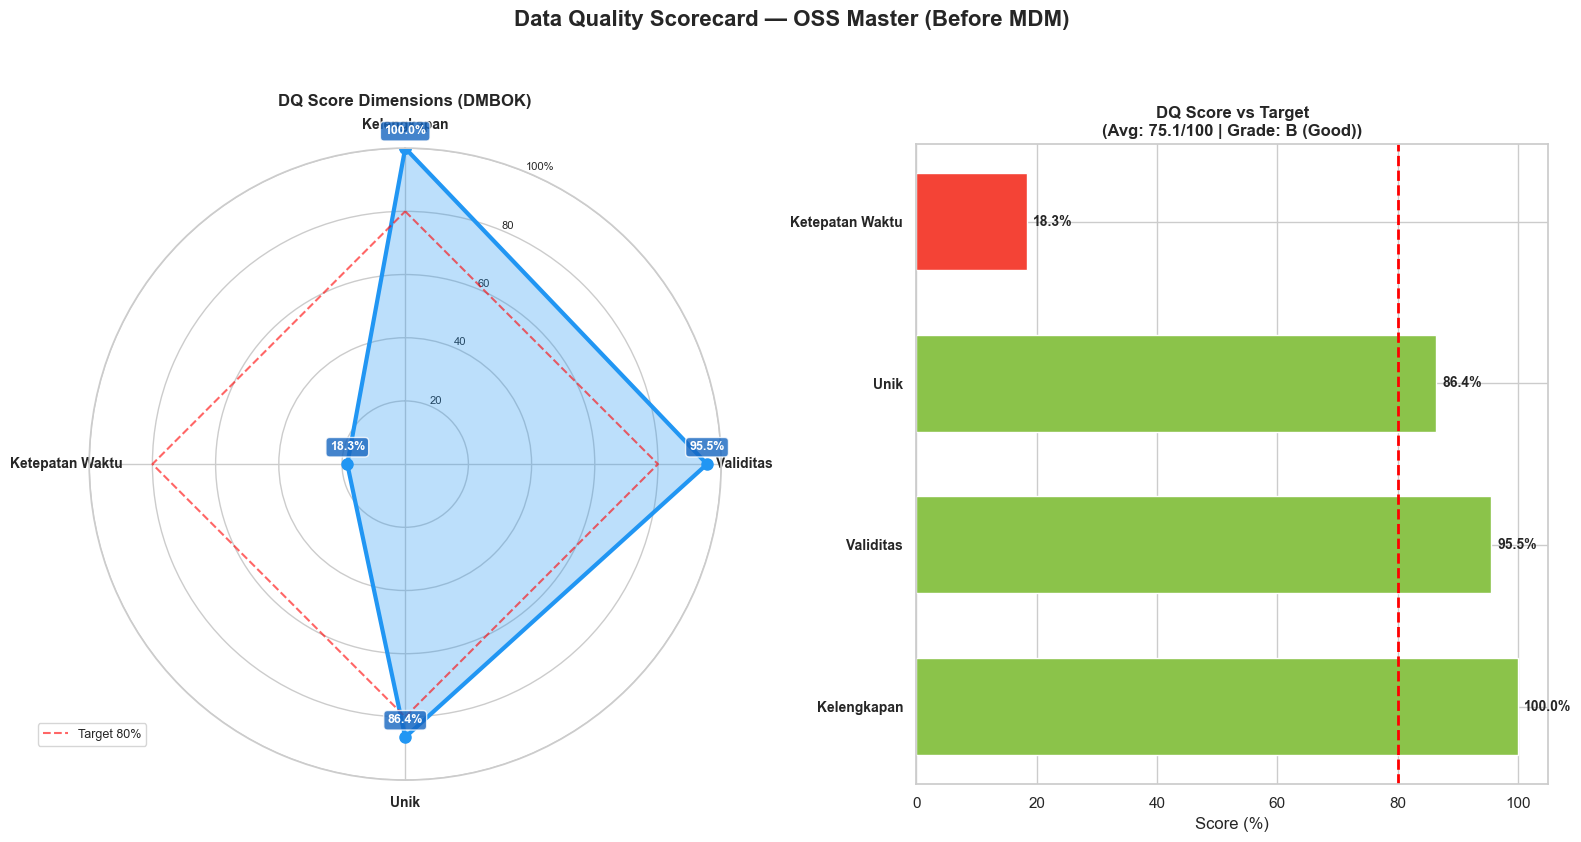


📊 Generating DQ Scorecard untuk CEISA Operational...
💾 Chart disimpan: reports/dq_scorecard_ceisa_operational.png


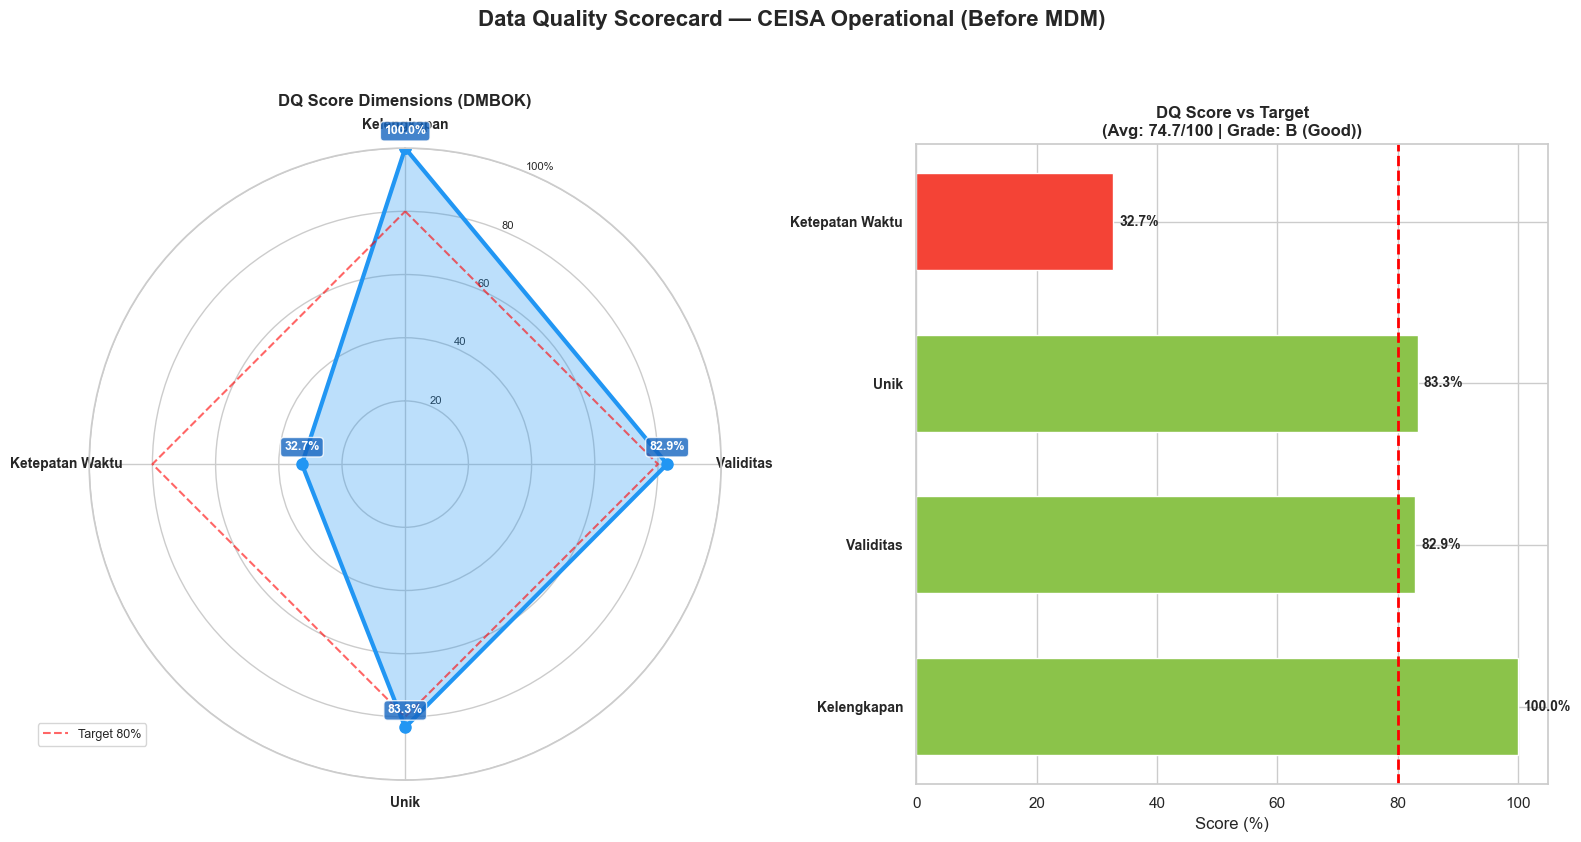


   FINAL BASELINE DMBOK SUMMARY (4-DIM)
OSS Master Overall Score       : 75.1/100
CEISA Operational Overall Score: 74.7/100


In [6]:
# ============================================================
# EKSEKUSI SIMULASI + PROFILING
# ============================================================

# --- 1. Jalankan simulasi ---
run_full_simulation()

# --- 2. Muat data yang baru dihasilkan ---
df_oss   = pd.read_csv('data/raw/oss_nib_data.csv')
df_ceisa = pd.read_csv('data/raw/ceisa_data.csv')

# --- 3. Tampilkan cuplikan data ---
print('\n' + '='*60)
print('   CUPLIKAN DATA OSS MASTER')
print('='*60)
display(df_oss.head(3))

print('\n' + '='*60)
print('   CUPLIKAN DATA CEISA OPERATIONAL')
print('='*60)
display(df_ceisa.head(3))

# --- 4. Scorecard untuk OSS Master ---
print('\n\U0001f4ca Generating DQ Scorecard untuk OSS Master...')
oss_metrics = calculate_dq_metrics(df_oss, 'OSS')
generate_professional_scorecard(oss_metrics, 'OSS Master')

# --- 5. Scorecard untuk CEISA Operational ---
print('\n\U0001f4ca Generating DQ Scorecard untuk CEISA Operational...')
ceisa_metrics = calculate_dq_metrics(df_ceisa, 'CEISA')
generate_professional_scorecard(ceisa_metrics, 'CEISA Operational')

# --- 6. Ringkasan Baseline ---
print('\n' + '='*45)
print('   FINAL BASELINE DMBOK SUMMARY (4-DIM)')
print('='*45)
print(f'OSS Master Overall Score       : {np.mean(list(oss_metrics.values())):.1f}/100')
print(f'CEISA Operational Overall Score: {np.mean(list(ceisa_metrics.values())):.1f}/100')
print('='*45)